In [29]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import json
import os

In [30]:
from azure.storage.blob import BlobServiceClient
import numpy as np
import io
from sklearn.model_selection import train_test_split

# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Blob file names
BLOB_NAMES = {
    "embeddings": "embeddings_checkpoint-2072.npy",
    "labels": "labels_checkpoint-2072.npy"
}

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Function to download and load .npy files
def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return np.load(io.BytesIO(blob_data))  # Load numpy file from bytes

# Load embeddings and labels
X = load_npy_from_azure(BLOB_NAMES["embeddings"])  # Features (embeddings)
y = load_npy_from_azure(BLOB_NAMES["labels"])      # Labels

# Print shape to verify
print("Feature matrix shape:", X.shape)  # (num_samples, embedding_dim)
print("Labels shape:", y.shape)          # (num_samples,)

words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0), ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0), ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1),
    ("grootmoeder", 0), ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0), ("jongen", 1), ("meisje", 0),
    ("jongetje", 1), ("meid", 0), ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0), ("peetvader", 1), ("peetmoeder", 0),
    ("bruidegom", 1), ("bruid", 0), ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1), ("dame", 0),
    ("kerel", 1), ("mister", 1), ("miss", 0), ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0), ("koning", 1),
    ("koningin", 0), ("lord", 1), ("lady", 0), ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0), ("mannelijk", 1), ("vrouwelijk", 0),
    ("gentleman", 1), ("gozer", 1), ("wijf", 0)
]

word_labels = dict(words_labels)
print("Word labels:", word_labels)

# Reconstruct embedding counts per word
word_embedding_counts = {}
current_idx = 0

for word, label in words_labels:
    count = 0
    while current_idx < len(y) and y[current_idx] == label:
        count += 1
        current_idx += 1
    word_embedding_counts[word] = count

print("Word embedding counts:", word_embedding_counts)

word_to_indices = {}
start_index = 0
for word, count in word_embedding_counts.items():
    word_to_indices[word] = list(range(start_index, start_index + count))
    start_index += count

# Ensure train-test split maintains label balance & prevents data leakage
train_groups = []
test_groups = []

for word, indices in word_to_indices.items():
    if len(indices) == 0:
        print(f"Skipping '{word}' due to zero embeddings.")
        continue
    train, test = train_test_split(
        indices, 
        test_size=0.2, 
        random_state=42, 
        stratify=[word_labels[word]] * len(indices)
    )
    train_groups.append(train)
    test_groups.append(test)

# Flatten the lists
train_indices = [idx for group in train_groups for idx in group]
test_indices = [idx for group in test_groups for idx in group]

# Ensure data is properly balanced
X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

# Print shapes and prin label balance
print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")
print(f"Training label distribution: {np.bincount(y_train)}")
print(f"Testing label distribution: {np.bincount(y_test)}")

Feature matrix shape: (117652, 768)
Labels shape: (117652,)
Word labels: {'man': 1, 'vrouw': 0, 'broer': 1, 'zus': 0, 'zoon': 1, 'dochter': 0, 'neef': 1, 'nicht': 0, 'vader': 1, 'moeder': 0, 'opa': 1, 'oma': 0, 'kleinzoon': 1, 'kleindochter': 0, 'grootvader': 1, 'grootmoeder': 0, 'oom': 1, 'tante': 0, 'papa': 1, 'mama': 0, 'jongen': 1, 'meisje': 0, 'jongetje': 1, 'meid': 0, 'schoonvader': 1, 'schoonmoeder': 0, 'schoonzoon': 1, 'schoondochter': 0, 'stiefvader': 1, 'stiefmoeder': 0, 'stiefzoon': 1, 'stiefdochter': 0, 'peetvader': 1, 'peetmoeder': 0, 'bruidegom': 1, 'bruid': 0, 'meneer': 1, 'mevrouw': 0, 'mijnheer': 1, 'heer': 1, 'dame': 0, 'kerel': 1, 'mister': 1, 'miss': 0, 'mr': 1, 'ms': 0, 'prins': 1, 'prinses': 0, 'koning': 1, 'koningin': 0, 'lord': 1, 'lady': 0, 'baron': 1, 'barones': 0, 'hertog': 1, 'hertogin': 0, 'monnik': 1, 'non': 0, 'hijzelf': 1, 'zijzelf': 0, 'mannelijk': 1, 'vrouwelijk': 0, 'gentleman': 1, 'gozer': 1, 'wijf': 0}
Word embedding counts: {'man': 19143, 'vrouw': 

In [31]:
# print an example of the first 10 training samples
print("First 10 training samples:")
print(X_train[:10])

First 10 training samples:
[[-1.278963   -0.3796027   0.04388007 ...  0.2597855   0.6899244
   0.5124782 ]
 [-0.94013655 -0.24561223 -0.23434345 ...  0.46571732  0.6631866
   0.23027612]
 [-1.0779834  -0.27051333 -0.3574319  ...  0.6463448   0.6546083
   0.42884567]
 ...
 [-0.54812694 -0.43392298 -0.80551046 ...  0.07040071  0.88466054
   0.87272245]
 [-0.9121483  -0.5899991  -0.20276047 ...  0.5471971   0.94902015
   0.05107991]
 [-1.059653   -1.0087461   0.03734626 ...  0.29178315  0.8184199
   0.23462084]]


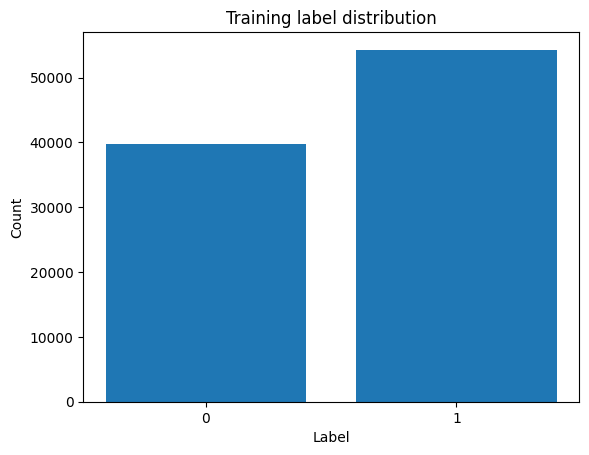

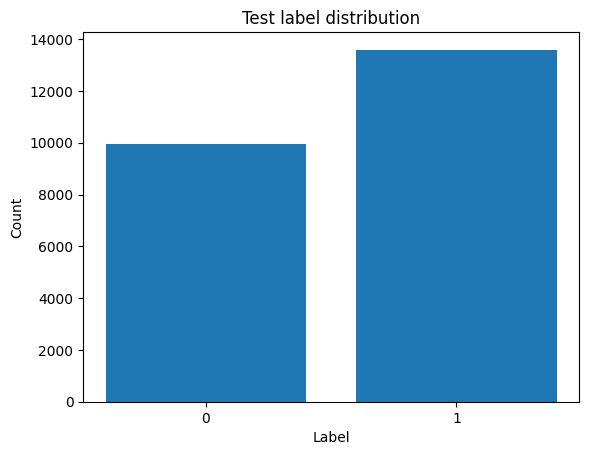

In [32]:
import matplotlib.pyplot as plt

# Plot the distribution of labels in the training set
plt.hist(y_train, bins=2, rwidth=0.8)
plt.xticks([0.25, 0.75], ['0', '1'])
plt.title("Training label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Plot the distribution of labels in the test set
plt.hist(y_test, bins=2, rwidth=0.8)
plt.xticks([0.25, 0.75], ['0', '1'])
plt.title("Test label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [33]:
# Print the number of features per sample
print("Number of features per sample:", X_train.shape[1])

Number of features per sample: 768


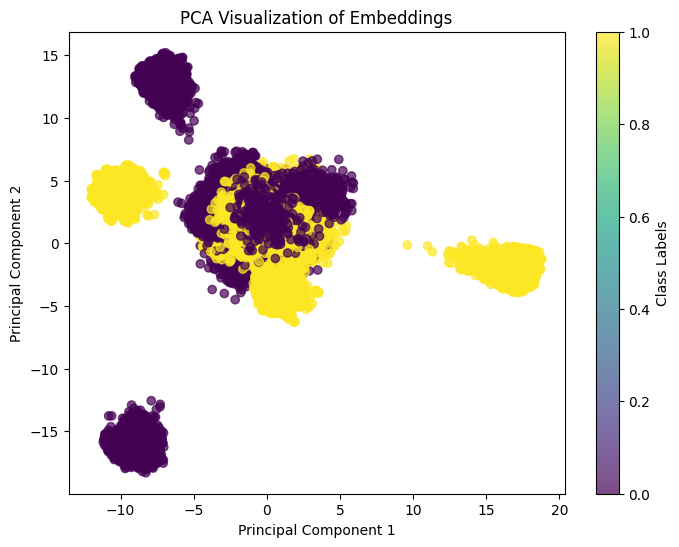

In [34]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Scatter plot of PCA-reduced features
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Class Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Embeddings")
plt.show()

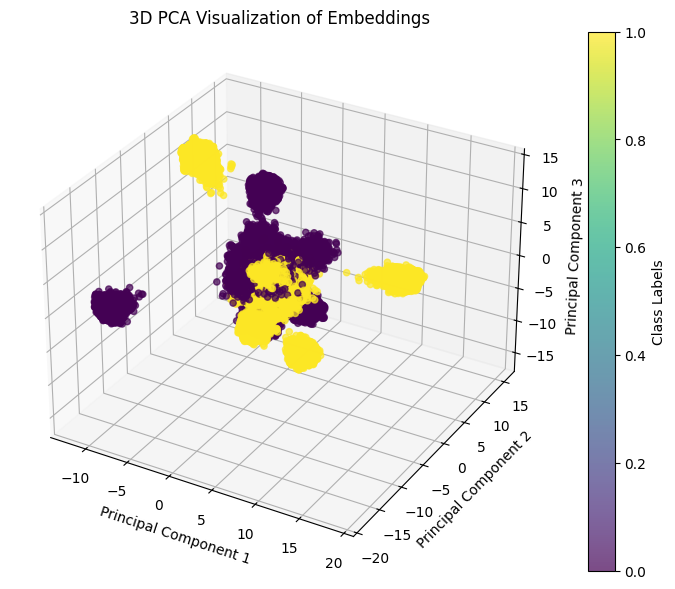

In [35]:
# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train)

# 3D Scatter plot of PCA-reduced features
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y_train, cmap='viridis', alpha=0.7)

# Labels and color bar
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Visualization of Embeddings")
plt.colorbar(scatter, label="Class Labels")

# Show plot
plt.show()

In [36]:
# Initialize SVM classifier with linear kernel
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [37]:
# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9961
           1       1.00      1.00      1.00     13591

    accuracy                           1.00     23552
   macro avg       1.00      1.00      1.00     23552
weighted avg       1.00      1.00      1.00     23552



In [28]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')


NameError: name 'classes' is not defined

<Figure size 800x600 with 0 Axes>

In [57]:
# Run svm again, but everytime with only one of the 768 features
accuracies = []

for i in range(X_train.shape[1]):
    # Select only one feature
    X_train_single = X_train[:, i].reshape(-1, 1)
    X_test_single = X_test[:, i].reshape(-1, 1)

    # Initialize SVM classifier
    svm_model = SVC(kernel="linear", C=1.0, random_state=42)

    # Train the model
    print(f"Training model with feature {i}")
    svm_model.fit(X_train_single, y_train)

    # Make predictions
    y_pred = svm_model.predict(X_test_single)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Feature {i}: Accuracy: {accuracy}")
    accuracies.append(accuracy)

# Get the feature with the highest accuracy
best_feature = np.argmax(accuracies)
best_accuracy = accuracies[best_feature]

print(f"Best feature: {best_feature}, Accuracy: {best_accuracy}")

Training model with feature 0
Feature 0: Accuracy: 0.7974630900395092
Training model with feature 1
Feature 1: Accuracy: 0.827199001871491
Training model with feature 2
Feature 2: Accuracy: 0.8702432938240798
Training model with feature 3
Feature 3: Accuracy: 0.8423788729465586
Training model with feature 4
Feature 4: Accuracy: 0.7974630900395092
Training model with feature 5
Feature 5: Accuracy: 0.7974630900395092
Training model with feature 6
Feature 6: Accuracy: 0.7974630900395092
Training model with feature 7
Feature 7: Accuracy: 0.7974630900395092
Training model with feature 8
Feature 8: Accuracy: 0.7974630900395092
Training model with feature 9
Feature 9: Accuracy: 0.8750259929299231
Training model with feature 10
Feature 10: Accuracy: 0.8380120607194843
Training model with feature 11
Feature 11: Accuracy: 0.7974630900395092
Training model with feature 12
Feature 12: Accuracy: 0.7974630900395092
Training model with feature 13
Feature 13: Accuracy: 0.7974630900395092
Training mode

KeyboardInterrupt: 

In [49]:
# Get the 5 best features
top_features = np.argsort(accuracies)[::-1][:5]
top_accuracies = [accuracies[i] for i in top_features]

print(f"Top 5 features: {top_features}, Accuracies: {top_accuracies}")

Top 5 features: [563 494 646 570 246], Accuracies: [0.6529803709706465, 0.6389339095984152, 0.63713308121736, 0.634431838645777, 0.634071672969566]


In [ ]:
# Run SVM with the best features
X_train_best = X_train[:, best_feature].reshape(-1, 1)
X_test_best = X_test[:, best_feature].reshape(-1, 1)

# Initialize SVM classifier
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train_best, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_best)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

print(f"accuracy with best features: {accuracy}")

accuracy with best features: 0.6529803709706465


In [51]:
# Run SVM with all but the best features
X_train_other = np.delete(X_train, best_feature, axis=1)
X_test_other = np.delete(X_test, best_feature, axis=1)

# Initialize SVM classifier
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train_other, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_other)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

print(f"accuracy without best features: {accuracy}")

accuracy without best features: 0.9902755267423015
